In [561]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from datetime import datetime

# 自作モジュールの読み込み
sys.path.append(os.path.abspath('..'))
from configs.config import *
from src.runner import Runner
from src.model_LGBM import model_LGBM
from src.util import Logger, Util

In [562]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# LGBM

In [563]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm")
# run_name = 'lgbm_202508012350'
run_name

'lgbm_202508021504'

In [584]:
df_all = Util.load_feature('Key').merge(
    Util.load_feature('Target'), how='left', on=['社員番号', 'category']
).merge(
    Util.load_feature('CategoryFeature'), how='left', on=['category']
).merge(
    Util.load_feature('CareerFeature'), how='left', on=['社員番号']
).merge(
    Util.load_feature('DxFeature'), how='left', on=['社員番号']
).merge(
    Util.load_feature('HrFeature'), how='left', on=['社員番号']
).merge(
    Util.load_feature('PositionHistoryFeature'), how='left', on=['社員番号']
).merge(
    Util.load_feature('UdemyActivityFeature'), how='left', on=['社員番号']
).merge(
    Util.load_feature('UdemyEmbedding'), how='left', on=['社員番号']
).merge(
    Util.load_feature('OvertimeWorkByMonthFeature'), how='left', on=['社員番号']
# ).merge(
#     Util.load_feature('OvertimeWorkByMonthTimeseriesFeature'), how='left', on=['社員番号']
)

In [585]:
# train/test
df_train = df_all[df_all['target'].notnull()]
df_test = df_all[df_all['target'].isnull()]
print('train shape: {}'.format(df_train.shape))
print('test shape: {}'.format(df_test.shape))

train shape: (7338, 555)
test shape: (11022, 555)


In [586]:
pos = sum(df_train['target'] == 1)
neg = sum(df_test['target'] != 1)
print(neg / pos)

38.13840830449827


In [587]:
def after_predict_process(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
        target_col(str): 予測値のカラム名
    Returns:    
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    return df_pred

def after_split_process(tr, va):
    """データセットの分割後に行う処理
    Args:
        tr(pd.DataFrame): 訓練データ
        va(pd.DataFrame): 検証データ
    returns:
        tr(pd.DataFrame): 訓練データ
        va(pd.DataFrame): 検証データ
    """
    return tr, va

model_params_lgb = {
    #### run params
    "key_cols": KEY_COL,                    # ユニークキー
    "target_col": TARGET_COL,              # 目的変数（0 or 1）
    "remove_cols": [],
    #### model train params
    "num_boost_round": 10000,
    "early_stopping_rounds": 100,
    "verbose": -1,
    "period": 100,
    "log_level": 'error',
    "verbosity": -1,
    #### model core params (for binary classification)
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': 'auc', # 'binary_logloss',
    # "is_unbalance": True,  # 不均衡データ対応
    # "scale_pos_weight": 10,  # 不均衡データ対応
    "max_depth": 15,
    "num_leaves": 6,
    "feature_fraction": 0.8,
    "bagging_freq": 1,
    "learning_rate": 0.01,
    "bagging_fraction": 0.8,
    "random_state": 42,
    "colsample_bytree": 0.9,
    "colsample_bynode": 0.6,
    "lambda_l1": 3.5,
    "lambda_l2": 1.5,
    "min_data_in_leaf": 50,
    "device": "cpu"
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "after_predict_process": after_predict_process,
    'after_split_process': after_split_process,  
}
cv_setting = {
    "target_col": TARGET_COL,
    "group_col": "社員番号",  # グループ化するカラム
    "n_splits": 4,  # 分割数,
    "shuffle": True,  # シャッフルするか否か
    "random_state": 42,  # ランダムシード
}

In [588]:
import importlib
from src import runner
from src import model_LGBM
from src import model
from configs import config

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)
importlib.reload(config)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import Runner
from src.model_LGBM import model_LGBM
from configs.config import *

In [589]:
memo = "LightGBM Overtime Work by Month Timeseries Feature 36か月に拡張"
ml_runner = Runner(
    run_name,
    model_LGBM,
    model_params_lgb,
    df_train,
    df_test,
    run_setting,
    cv_setting,
    logger,
    memo,
)

In [590]:
# ml_runner.tune_params(30)

In [591]:
ml_runner.run_train_cv()

[2025-08-02 15:09:59] - lgbm_202508021504 - start training cv
[2025-08-02 15:09:59] - lgbm_202508021504 fold 0 - start training


Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.777208	eval's auc: 0.676382
Early stopping, best iteration is:
[53]	train's auc: 0.763719	eval's auc: 0.683136


[2025-08-02 15:10:01] - lgbm_202508021504 fold 0 - end training
[2025-08-02 15:10:01] - lgbm_202508021504 fold 1 - start training


Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.768563	eval's auc: 0.694273
Early stopping, best iteration is:
[3]	train's auc: 0.724265	eval's auc: 0.707491


[2025-08-02 15:10:02] - lgbm_202508021504 fold 1 - end training
[2025-08-02 15:10:02] - lgbm_202508021504 fold 2 - start training


Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.787426	eval's auc: 0.671945
Early stopping, best iteration is:
[35]	train's auc: 0.771723	eval's auc: 0.678692


[2025-08-02 15:10:04] - lgbm_202508021504 fold 2 - end training
[2025-08-02 15:10:04] - lgbm_202508021504 fold 3 - start training


Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.783285	eval's auc: 0.664223
Early stopping, best iteration is:
[92]	train's auc: 0.781149	eval's auc: 0.66543


[2025-08-02 15:10:06] - lgbm_202508021504 fold 3 - end training
[2025-08-02 15:10:06] - lgbm_202508021504 - end training cv


In [592]:
ml_runner.run_metric_cv()

[2025-08-02 15:10:06] - lgbm_202508021504 - start metric cv
100%|██████████| 4/4 [00:01<00:00,  2.87it/s]
memo: LightGBM Overtime Work by Month Timeseries Feature 36か月に拡張
run_name:lgbm_202508021504	score_mean:0.683687347684585	score0:0.6831364492381442	score1:0.7074910300166273	score2:0.6786921031966169	score3:0.6654298082869512
all: 0.6458480699365441, mean: 0.683687347684585, std: 0.015208624148931083
[2025-08-02 15:10:07] - mean: 0.683687347684585, std: 0.015208624148931083
[2025-08-02 15:10:08] - output predict : g:\マイドライブ\competitions\atma_udemy\models\lgbm_202508021504\va_pred.pkl
[2025-08-02 15:10:08] - lgbm_202508021504 - end metric cv


In [593]:
ml_runner.run_predict_cv()

[2025-08-02 15:10:08] - lgbm_202508021504 - start prediction cv
100%|██████████| 4/4 [00:00<00:00, 10.46it/s]
[2025-08-02 15:10:08] - output predict : g:\マイドライブ\competitions\atma_udemy\models\lgbm_202508021504\te_pred.pkl
[2025-08-02 15:10:08] - lgbm_202508021504 - end prediction cv


In [594]:
ml_runner.plot_feature_importance_cv()

[2025-08-02 15:10:08] - lgbm_202508021504 - start plot feature importance cv
[2025-08-02 15:10:18] - lgbm_202508021504 - end plot feature importance cv


In [595]:
tr, va = ml_runner.create_train_valid_dateset(0)
print("train shape: {}".format(tr.shape))
print("valid shape: {}".format(va.shape))

train shape: (5502, 555)
valid shape: (1836, 555)


# Submissionの作成

In [596]:
runner = ml_runner

In [597]:
df_te_pred = pd.read_pickle(os.path.join(runner.out_dir_name, "te_pred.pkl"))
df_prep_test = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_test.pkl"))
df_pred = pd.merge(df_prep_test, df_te_pred, on=["社員番号", "category"], how="left")
df_submit = df_pred[['target']]

In [598]:
path_submit = os.path.join(DIR_SUBMISSIONS, f"{runner.run_name}_submition.csv")
df_submit.to_csv(path_submit, header=True, index=False)
print(path_submit)
pd.read_csv(path_submit)

g:\マイドライブ\competitions\atma_udemy\data\submission\lgbm_202508021504_submition.csv


,target
0,0.043021
1,0.043511
2,0.043511
3,0.043511
4,0.043290
...,...
11017,0.038964
11018,0.038964
11019,0.038964
11020,0.038913


# モデル分析

In [599]:
df_submit['target'].describe()


count    11022.000000
mean         0.039643
std          0.005952
min          0.030402
25%          0.034583
50%          0.040435
75%          0.043987
max          0.059675
Name: target, dtype: float64

<Axes: >

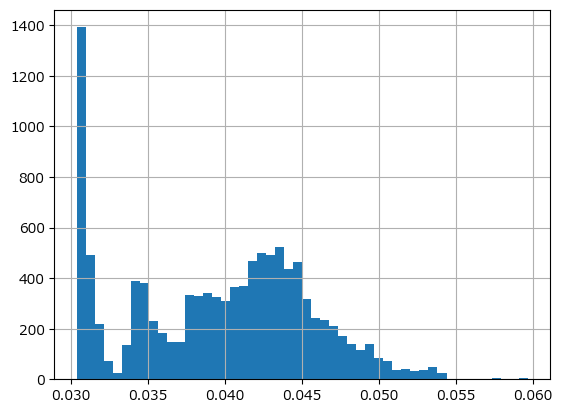

In [600]:
df_submit['target'].hist(bins=50)

In [601]:
df_va_pred = pd.read_pickle(os.path.join(runner.out_dir_name, "va_pred.pkl"))
target = Util.load_feature('Target')
df_va_target = pd.merge(df_va_pred, target, on=['社員番号', 'category'], how='left', suffixes=('_pred', '_true'))

In [602]:
df_va_target

,社員番号,category,target_pred,target_true
0,-2Sq3E0WkZj8pL7jxdL3Cg==,コンテンツ・サービス・デザイン,0.029361,0
1,-2Sq3E0WkZj8pL7jxdL3Cg==,コーポレート管理部門/技術・データ・BPR,0.029361,0
2,-2Sq3E0WkZj8pL7jxdL3Cg==,プロダクトマネジメント,0.029361,0
3,-2Sq3E0WkZj8pL7jxdL3Cg==,マーケティング,0.029361,0
4,-2Sq3E0WkZj8pL7jxdL3Cg==,事業企画・開発・研究,0.029361,0
...,...,...,...,...
7333,zuplFpzBoM4c1dFy5HPXqg==,コーポレート管理部門/技術・データ・BPR,0.062537,0
7334,zuplFpzBoM4c1dFy5HPXqg==,プロダクトマネジメント,0.062537,0
7335,zuplFpzBoM4c1dFy5HPXqg==,マーケティング,0.062537,0
7336,zuplFpzBoM4c1dFy5HPXqg==,事業企画・開発・研究,0.061751,0


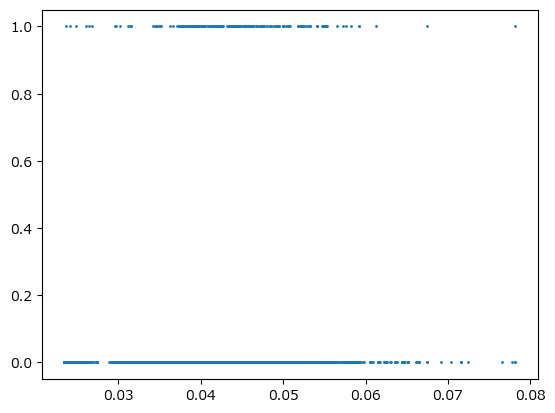

In [603]:
plt.plot(df_va_target['target_pred'], df_va_target['target_true'], marker='o', linestyle='', markersize=1)